In [1]:
%matplotlib inline

In [2]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
)

In [5]:
from xgboost import XGBRegressor

In [6]:
RANDOM_STATE = 42
USE_GPU = True
N_COMPONENTS = 20  # fixed PCA fit, from prior dimensionality ablation

In [7]:
# ---- 0. Paths ----
DATA_DIR = r"E:\NSU\cse445\EDA attempt3\Dataset\ML dataset"
TRAIN_FILE = f"{DATA_DIR}/ML_train.csv"
TEST_FILE = f"{DATA_DIR}/ML_test.csv"
BERT_FILE = r"E:\NSU\cse445\EDA attempt3\NLP models\embeddings\bert_embeddings.csv"

In [8]:
# ---- 1. Fixed best hyperparameters (from bert_xgb_bayes_best_params.json) ----
BEST_PARAMS = {
    "colsample_bytree": 0.9512165066659852,
    "learning_rate": 0.07643904937766527,
    "max_depth": 6,
    "min_child_weight": 7,
    "n_estimators": 459,
    "reg_alpha": 0.0014729254229045347,
    "reg_lambda": 0.845771345696438,
    "subsample": 0.8060762192885254,
}

In [9]:
# ---- 2. Load data + fixed PCA (N=20) ----
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)
bert_raw = pd.read_csv(BERT_FILE)

In [10]:
TARGET_RAW = "target_usd"
TARGET_LOG = "log_target"
DROP_FROM_X = ["id", "target_usd", "log_target", "goal_usd"]

In [11]:
train_ids = set(train_df["id"])
feature_cols = [c for c in bert_raw.columns if c != "id"]
train_mask = bert_raw["id"].isin(train_ids)

In [12]:
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
pca.fit(bert_raw.loc[train_mask, feature_cols])
reduced_all = pca.transform(bert_raw[feature_cols])
reduced_cols = [f"bert_pca_{i}" for i in range(N_COMPONENTS)]
reduced_df = pd.DataFrame(reduced_all, columns=reduced_cols)
reduced_df.insert(0, "id", bert_raw["id"].values)

In [13]:
merged_train = train_df.merge(reduced_df, on="id", how="left")
merged_test = test_df.merge(reduced_df, on="id", how="left")

In [14]:
X_train_full = merged_train.drop(columns=DROP_FROM_X, errors="ignore")
X_test_full = merged_test.drop(columns=DROP_FROM_X, errors="ignore")
y_train = merged_train[TARGET_LOG].copy()
y_test = merged_test[TARGET_LOG].copy()
actual_usd = merged_test[TARGET_RAW].to_numpy()

In [15]:
assert list(X_train_full.columns) == list(X_test_full.columns)
print(f"Full feature count: {X_train_full.shape[1]}")

Full feature count: 97


In [16]:
# ---- 3. Evaluation helper ----
def evaluate_model(y_true_log, pred_log, actual_usd):
    pred_usd = np.expm1(pred_log)
    pred_usd = np.clip(pred_usd, a_min=0, a_max=None)

    mae_log = mean_absolute_error(y_true_log, pred_log)
    mse_log = mean_squared_error(y_true_log, pred_log)
    rmse_log = np.sqrt(mse_log)
    r2_log = r2_score(y_true_log, pred_log)

    mae_usd = mean_absolute_error(actual_usd, pred_usd)
    mse_usd = mean_squared_error(actual_usd, pred_usd)
    rmse_usd = np.sqrt(mse_usd)
    r2_usd = r2_score(actual_usd, pred_usd)

    rmsle = np.sqrt(mean_squared_log_error(actual_usd, pred_usd))

    return {
        "MAE_log": mae_log, "MSE_log": mse_log, "RMSE_log": rmse_log, "R2_log": r2_log,
        "MAE_USD": mae_usd, "MSE_USD": mse_usd, "RMSE_USD": rmse_usd, "R2_USD": r2_usd,
        "RMSLE": rmsle
    }

In [17]:
def fit_and_eval(X_train, X_test):
    model = XGBRegressor(
        objective="reg:squarederror", eval_metric="rmse",
        tree_method="hist", device="cuda" if USE_GPU else "cpu",
        random_state=RANDOM_STATE,
        **BEST_PARAMS,
    )
    model.fit(X_train, y_train)
    pred_log = model.predict(X_test)
    return evaluate_model(y_test, pred_log, actual_usd), model

In [18]:
# ---- 4. Fit on ALL 20 components first -> get importance ranking of bert_pca_* ----
metrics_all20, model_all20 = fit_and_eval(X_train_full, X_test_full)

In [19]:
importances = pd.Series(model_all20.feature_importances_, index=X_train_full.columns)
bert_importances = importances[reduced_cols].sort_values(ascending=False)
print("\nBERT PCA component importance ranking:")
print(bert_importances)


BERT PCA component importance ranking:
bert_pca_2     0.119904
bert_pca_7     0.068653
bert_pca_12    0.033196
bert_pca_14    0.029651
bert_pca_5     0.026735
bert_pca_1     0.017716
bert_pca_16    0.015710
bert_pca_8     0.013744
bert_pca_11    0.013080
bert_pca_19    0.009667
bert_pca_18    0.009575
bert_pca_10    0.008544
bert_pca_17    0.008095
bert_pca_9     0.007916
bert_pca_6     0.006884
bert_pca_13    0.006745
bert_pca_4     0.006536
bert_pca_15    0.005893
bert_pca_0     0.005862
bert_pca_3     0.005234
dtype: float32


In [20]:
ranked_bert_cols = bert_importances.index.tolist()

In [27]:
# ---- 5. Ablation loop: top-5, top-10, top-15, top-20 ----
TOP_N_LIST = [5, 10, 15, 20, 25, 30]
non_bert_cols = [c for c in X_train_full.columns if c not in reduced_cols]

In [28]:
ablation_results = []

In [29]:
for top_n in TOP_N_LIST:
    print(f"\n{'='*70}")
    print(f"TOP_N = {top_n} PCA components")
    print(f"{'='*70}")

    keep_cols = non_bert_cols + ranked_bert_cols[:top_n]
    X_train_sub = X_train_full[keep_cols]
    X_test_sub = X_test_full[keep_cols]

    if top_n == 20:
        metrics = metrics_all20  # reuse, already computed
    else:
        metrics, _ = fit_and_eval(X_train_sub, X_test_sub)

    metrics["Top_N"] = top_n
    metrics["N_Features_Total"] = X_train_sub.shape[1]
    ablation_results.append(metrics)

    print(f"RMSLE={metrics['RMSLE']:.4f} | R2_log={metrics['R2_log']:.4f} | "
          f"R2_USD={metrics['R2_USD']:.4f}")


TOP_N = 5 PCA components
RMSLE=1.6025 | R2_log=0.7261 | R2_USD=0.1437

TOP_N = 10 PCA components
RMSLE=1.5307 | R2_log=0.7491 | R2_USD=0.1792

TOP_N = 15 PCA components
RMSLE=1.4973 | R2_log=0.7605 | R2_USD=0.1595

TOP_N = 20 PCA components
RMSLE=1.5065 | R2_log=0.7578 | R2_USD=0.1769

TOP_N = 25 PCA components
RMSLE=1.4975 | R2_log=0.7606 | R2_USD=0.1464

TOP_N = 30 PCA components
RMSLE=1.4975 | R2_log=0.7606 | R2_USD=0.1464


In [24]:
# ---- 6. Results table ----
results_df = pd.DataFrame(ablation_results)
results_df = results_df[[
    "Top_N", "N_Features_Total",
    "MAE_log", "MSE_log", "RMSE_log", "R2_log",
    "MAE_USD", "MSE_USD", "RMSE_USD", "R2_USD", "RMSLE"
]]
print("\n" + "="*70)
print("ABLATION RESULTS: Top-N PCA components (importance-ranked)")
print("="*70)
print(results_df)


ABLATION RESULTS: Top-N PCA components (importance-ranked)
   Top_N  N_Features_Total   MAE_log   MSE_log  RMSE_log    R2_log  \
0      5                82  1.181063  2.573672  1.604267  0.726052   
1     10                87  1.135646  2.356805  1.535189  0.749136   
2     15                92  1.103607  2.249955  1.499985  0.760509   
3     20                97  1.115845  2.275488  1.508472  0.757791   

        MAE_USD       MSE_USD       RMSE_USD    R2_USD     RMSLE  
0  14902.848112  1.010520e+10  100524.647281  0.143735  1.602470  
1  14482.659663  9.686516e+09   98420.098786  0.179213  1.530679  
2  14666.704874  9.919666e+09   99597.521706  0.159457  1.497336  
3  14587.044370  9.713670e+09   98557.950385  0.176912  1.506474  


In [25]:
results_df.to_csv("topn_pca_dropout_results.csv", index=False)
bert_importances.to_csv("bert_pca_importance_ranking.csv")
print("\nSaved: topn_pca_dropout_results.csv")
print("Saved: bert_pca_importance_ranking.csv")


Saved: topn_pca_dropout_results.csv
Saved: bert_pca_importance_ranking.csv


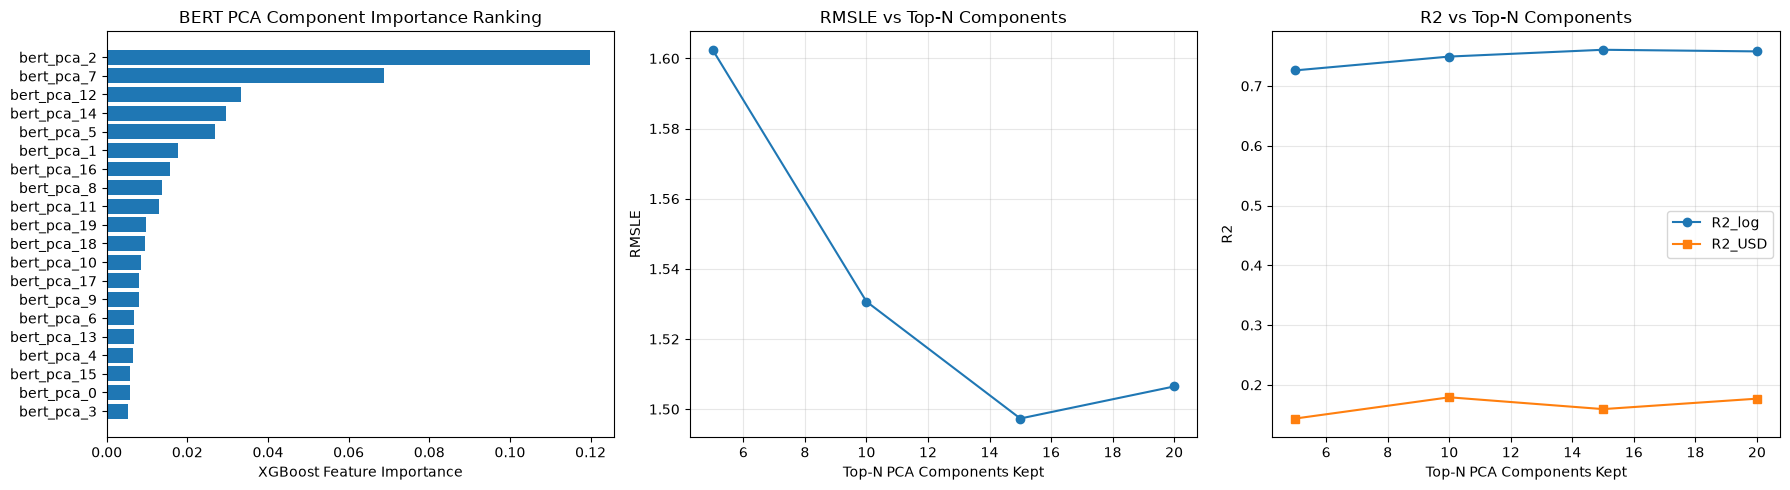

Saved: topn_pca_dropout_plot.png


In [26]:
# ---- 7. Plot (single cell: importance ranking + RMSLE + R2) ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].barh(bert_importances.index[::-1], bert_importances.values[::-1])
axes[0].set_xlabel("XGBoost Feature Importance")
axes[0].set_title("BERT PCA Component Importance Ranking")
axes[1].plot(results_df["Top_N"], results_df["RMSLE"], marker="o")
axes[1].set_xlabel("Top-N PCA Components Kept")
axes[1].set_ylabel("RMSLE")
axes[1].set_title("RMSLE vs Top-N Components")
axes[1].grid(True, alpha=0.3)
axes[2].plot(results_df["Top_N"], results_df["R2_log"], marker="o", label="R2_log")
axes[2].plot(results_df["Top_N"], results_df["R2_USD"], marker="s", label="R2_USD")
axes[2].set_xlabel("Top-N PCA Components Kept")
axes[2].set_ylabel("R2")
axes[2].set_title("R2 vs Top-N Components")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("topn_pca_dropout_plot.png", dpi=150)
plt.show()
print("Saved: topn_pca_dropout_plot.png")